In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [16]:
games_df = pd.read_parquet("games_dataset.parquet").drop(columns=['engine', 'depth', 'pv'])
moves_df = pd.read_parquet("moves_dataset.parquet")
df = moves_df.merge(games_df, on="game_id", suffixes=("_move","_game"))
df.head()

,game_id,move_number,phase,classification,time_spent,san,white,black,rating,accuracy,...,splendid,perfect,best,excellent,good,opening,inaccuracy,mistake,blunder,forced
0,00001,1,opening,Opening,0.1,e4,rastone98,Ragalesh,939,50.2,...,0,1,8,6,2,1,3,2,1,1
1,00001,3,opening,Best,1.4,exd5,rastone98,Ragalesh,939,50.2,...,0,1,8,6,2,1,3,2,1,1
2,00001,5,opening,Best,0.6,Nc3,rastone98,Ragalesh,939,50.2,...,0,1,8,6,2,1,3,2,1,1
3,00001,7,opening,Excellent,2.6,Nf3,rastone98,Ragalesh,939,50.2,...,0,1,8,6,2,1,3,2,1,1
4,00001,9,opening,Excellent,2.0,Bc4,rastone98,Ragalesh,939,50.2,...,0,1,8,6,2,1,3,2,1,1


In [17]:
PLAYER = 'rastone98'
total_games = len(games_df)
wins = ((games_df['white'] == PLAYER) & (games_df['result'] == '1-0')) | \
       ((games_df['black'] == PLAYER) & (games_df['result'] == '0-1'))
num_wins = wins.sum()
win_rate = num_wins / total_games * 100
print(f"Win rate generale di {PLAYER}: {win_rate:.2f}%")
player_games = games_df[(games_df['white'] == PLAYER) | (games_df['black'] == PLAYER)]

# aggiungi colonna outcome dal punto di vista del player
player_games['outcome'] = [
    'win'  if (r['white'] == PLAYER and r['result']=='1-0') or (r['black']==PLAYER and r['result']=='0-1')
    else 'loss' if (r['white']==PLAYER and r['result']=='0-1') or (r['black']==PLAYER and r['result']=='1-0')
    else 'draw'
    for i,r in player_games.iterrows()
]

# aggiungi colonna colore del player
player_games['color'] = ['white' if r['white']==PLAYER else 'black' for i,r in player_games.iterrows()]

# raggruppa per colore e outcome, conta partite
summary = player_games.groupby(['color','outcome']).size().unstack(fill_value=0)

# calcola percentuali
summary_percent = round(summary.div(summary.sum(axis=1), axis=0) * 100, 2)

# stampa
print("Conteggio partite per colore e outcome:")
print(summary)

print("\nPercentuali partite per colore:")
print(summary_percent)

Win rate generale di rastone98: 42.31%
Conteggio partite per colore e outcome:
outcome  draw  loss  win
color                   
black       1     5    7
white       1     8    4

Percentuali partite per colore:
outcome  draw   loss    win
color                      
black    7.69  38.46  53.85
white    7.69  61.54  30.77


In [18]:
# aggiungi colonna outcome dal punto di vista del player
df['outcome'] = [
    'win'  if (r['white'] == PLAYER and r['result']=='1-0') or (r['black']==PLAYER and r['result']=='0-1')
    else 'loss' if (r['white'] == PLAYER and r['result']=='0-1') or (r['black']==PLAYER and r['result']=='1-0')
    else 'draw'
    for i,r in df.iterrows()
]

# seleziona colonne di interesse
errors_df = df[['outcome','splendid','perfect','best','excellent','good','num_moves']]

# calcola media pesata per outcome
weighted_means_outcome = errors_df.groupby('outcome').apply(
    lambda x: pd.Series({
        'splendid': (x['splendid'] * x['num_moves']).sum() / x['num_moves'].sum(),
        'perfect':   (x['perfect']   * x['num_moves']).sum() / x['num_moves'].sum(),
        'best':   (x['best']   * x['num_moves']).sum() / x['num_moves'].sum(),
        'excellent':   (x['excellent']   * x['num_moves']).sum() / x['num_moves'].sum(),
        'good':   (x['good']   * x['num_moves']).sum() / x['num_moves'].sum(),
    })
)

# arrotonda e visualizza
display(weighted_means_outcome.round(2).style.background_gradient('Greens', vmin=0, vmax=weighted_means_outcome.max().max()).format("{:.2f}"))

,splendid,perfect,best,excellent,good
outcome,,,,,
draw,0.00,2.61,11.39,6.09,6.18
loss,0.00,1.39,12.19,8.30,6.06
win,0.00,1.78,13.93,16.80,5.27


In [19]:
# aggiungi colonna colore del player
df['color'] = ['white' if r['white']==PLAYER else 'black' for i,r in df.iterrows()]

# seleziona solo colonne di interesse
errors_df = df[['color','splendid','perfect','best','excellent','good','num_moves']]

# raggruppa per fase e colore, calcola media pesata
weighted_means_color = errors_df.groupby(['color']).apply(
    lambda x: pd.Series({
        'splendid': (x['splendid'] * x['num_moves']).sum() / x['num_moves'].sum(),
        'perfect':   (x['perfect']   * x['num_moves']).sum() / x['num_moves'].sum(),
        'best':   (x['best']   * x['num_moves']).sum() / x['num_moves'].sum(),
        'excellent':   (x['excellent']   * x['num_moves']).sum() / x['num_moves'].sum(),
        'good':   (x['good']   * x['num_moves']).sum() / x['num_moves'].sum(),
    })
)

# visualizzazione con gradiente
display(weighted_means_color.style.background_gradient('Greens', vmin=0, vmax=weighted_means_color.max().max()).format("{:.2f}"))

,splendid,perfect,best,excellent,good
color,,,,,
black,0.00,1.61,14.20,15.30,5.92
white,0.00,1.90,10.65,6.22,5.33


In [20]:
errors_df = df[['phase', 'splendid','perfect','best','excellent','good', 'num_moves']]
weighted_means = errors_df.groupby('phase').apply(
    lambda x: pd.Series({
        'splendid': (x['splendid'] * x['num_moves']).sum() / x['num_moves'].sum(),
        'perfect':   (x['perfect']   * x['num_moves']).sum() / x['num_moves'].sum(),
        'best':   (x['best']   * x['num_moves']).sum() / x['num_moves'].sum(),
        'excellent':   (x['excellent']   * x['num_moves']).sum() / x['num_moves'].sum(),
        'good':   (x['good']   * x['num_moves']).sum() / x['num_moves'].sum(),
    })
)
display(weighted_means.style.background_gradient('Greens', vmin=0, vmax=weighted_means.max().max()).format("{:.2f}"))

,splendid,perfect,best,excellent,good
phase,,,,,
endgame,0.00,1.74,16.29,17.56,6.49
middlegame,0.00,1.75,11.62,9.47,5.57
opening,0.00,1.64,10.69,8.92,4.96


In [21]:
# aggiungi colonna colore del player
df['color'] = ['white' if r['white']==PLAYER else 'black' for i,r in df.iterrows()]

# seleziona solo colonne di interesse
errors_df = df[['phase','color','splendid','perfect','best','excellent','good','num_moves']]

# raggruppa per fase e colore, calcola media pesata
weighted_means_color = errors_df.groupby(['color','phase']).apply(
    lambda x: pd.Series({
        'splendid': (x['splendid'] * x['num_moves']).sum() / x['num_moves'].sum(),
        'perfect':   (x['perfect']   * x['num_moves']).sum() / x['num_moves'].sum(),
        'best':   (x['best']   * x['num_moves']).sum() / x['num_moves'].sum(),
        'excellent':   (x['excellent']   * x['num_moves']).sum() / x['num_moves'].sum(),
        'good':   (x['good']   * x['num_moves']).sum() / x['num_moves'].sum(),
    })
)

# visualizzazione con gradiente
display(weighted_means_color.style.background_gradient('Greens', vmin=0, vmax=weighted_means_color.max().max()).format("{:.2f}"))

In [22]:
# aggiungi colonna outcome dal punto di vista del player
df['outcome'] = [
    'win'  if (r['white'] == PLAYER and r['result']=='1-0') or (r['black']==PLAYER and r['result']=='0-1')
    else 'loss' if (r['white'] == PLAYER and r['result']=='0-1') or (r['black']==PLAYER and r['result']=='1-0')
    else 'draw'
    for i,r in df.iterrows()
]

# aggiungi colonna colore
df['color'] = ['white' if r['white']==PLAYER else 'black' for i,r in df.iterrows()]

# seleziona colonne di interesse
errors_df = df[['phase','color','outcome','splendid','perfect','best','excellent','good','num_moves']]

# raggruppa per fase, colore e outcome e calcola media pesata
weighted_means_all = errors_df.groupby(['phase','color','outcome']).apply(
    lambda x: pd.Series({
        'splendid': (x['splendid'] * x['num_moves']).sum() / x['num_moves'].sum(),
        'perfect':   (x['perfect']   * x['num_moves']).sum() / x['num_moves'].sum(),
        'best':   (x['best']   * x['num_moves']).sum() / x['num_moves'].sum(),
        'excellent':   (x['excellent']   * x['num_moves']).sum() / x['num_moves'].sum(),
        'good':   (x['good']   * x['num_moves']).sum() / x['num_moves'].sum(),
    })
)
# creiamo una colonna combinata colore + outcome
weighted_means_all = weighted_means_all.reset_index()
weighted_means_all['color_outcome'] = weighted_means_all['color'] + '_' + weighted_means_all['outcome']

# pivot: fase sulle colonne, colore+outcome sulle righe
pivot_df = weighted_means_all.pivot(index='color_outcome', columns='phase', values=['splendid','perfect','best','excellent','good'])

# visualizza con gradiente e arrotondamento
display(
    pivot_df.round(2)
    .style
    .background_gradient('Greens', vmin=0, vmax=pivot_df.max().max())
    .format("{:.2f}")
)

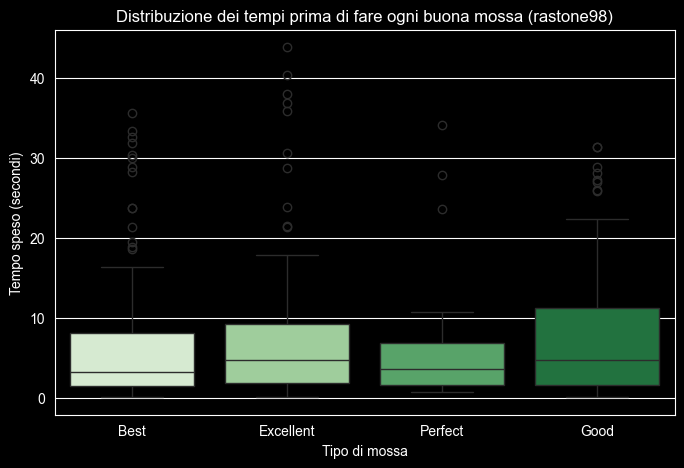

In [23]:
# boxplot: x = tipo di errore, y = tempo impiegato
error_moves = moves_df[moves_df['classification'].isin(['Splendid','Perfect','Best','Excellent','Good'])]

plt.figure(figsize=(8,5))
sns.boxplot(
    data=error_moves,
    x='classification',
    y='time_spent',
    hue='classification',    # aggiungi hue
    palette='Greens',
    dodge=False,             # evita duplicazioni
)
plt.ylabel("Tempo speso (secondi)")
plt.xlabel("Tipo di mossa")
plt.title(f"Distribuzione dei tempi prima di fare ogni buona mossa ({PLAYER})")
plt.show()

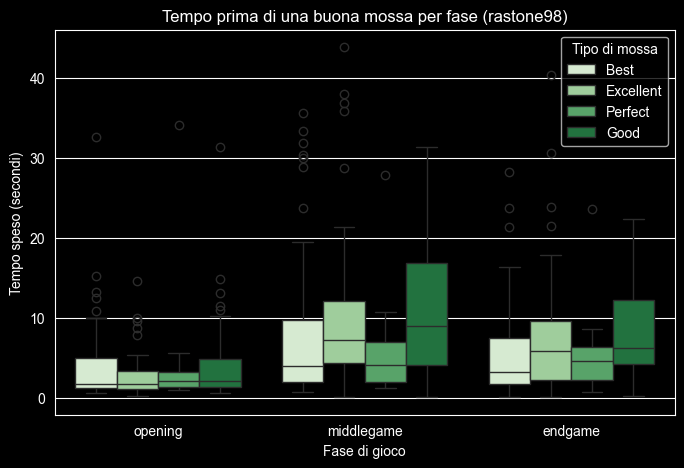

In [24]:
# seleziona solo le mosse con errori
error_moves = moves_df[moves_df['classification'].isin(['Splendid','Perfect','Best','Excellent','Good'])]

plt.figure(figsize=(8,5))
sns.boxplot(
    data=error_moves,
    x='phase',
    y='time_spent',
    hue='classification',
    palette='Greens',
    dodge=True
)
plt.ylabel("Tempo speso (secondi)")
plt.xlabel("Fase di gioco")
plt.title(f"Tempo prima di una buona mossa per fase ({PLAYER})")
plt.legend(title="Tipo di mossa")
plt.show()

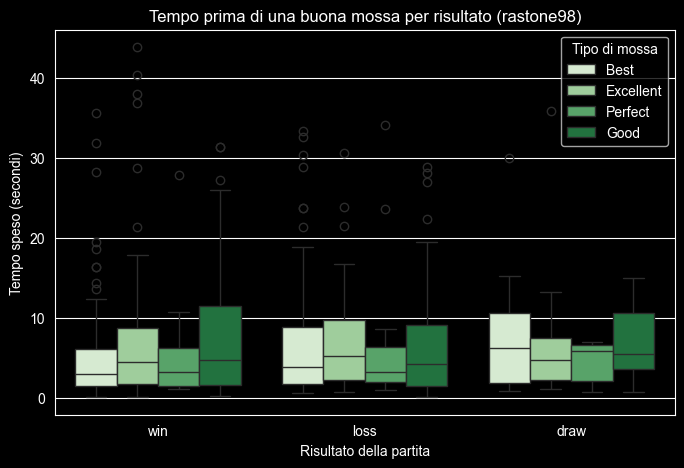

In [25]:
error_moves = df[df['classification'].isin(['Splendid','Perfect','Best','Excellent','Good'])]

plt.figure(figsize=(8,5))
sns.boxplot(
    data=error_moves,
    x='outcome',          # risultato della partita
    y='time_spent',       # tempo speso prima della mossa
    hue='classification', # tipo di errore
    palette='Greens',
    dodge=True
)
plt.ylabel("Tempo speso (secondi)")
plt.xlabel("Risultato della partita")
plt.title(f"Tempo prima di una buona mossa per risultato ({PLAYER})")
plt.legend(title="Tipo di mossa")
plt.show()

In [26]:
# seleziona le mosse buone
good_moves = df[df['classification'].isin(['Splendid','Perfect','Best','Excellent','Good'])]

# tempo medio per tipo di mossa
good_time_means = good_moves.groupby('classification')['time_spent'].mean().round(2)
print("Tempo medio per tipo di mossa buona:")
print(good_time_means)
good_counts = good_moves['classification'].value_counts()
good_percent = (good_counts / good_counts.sum() * 100).round(1)

print("Conteggio mosse d'errore:")
print(good_counts)
print("\nPercentuale mosse d'errore:")
print(good_percent)

Tempo medio per tipo di mossa buona:
classification
Best         6.03
Excellent    7.19
Good         7.63
Perfect      5.92
Name: time_spent, dtype: float64
Conteggio mosse d'errore:
classification
Best         213
Excellent    159
Good         106
Perfect       37
Name: count, dtype: int64

Percentuale mosse d'errore:
classification
Best         41.4
Excellent    30.9
Good         20.6
Perfect       7.2
Name: count, dtype: float64


In [27]:
good_moves = df[df['classification'].isin(['Splendid','Perfect','Best','Excellent','Good'])]

# media pesata per numero di mosse (qui useremo semplicemente il tempo)
weighted_good_time = good_moves.groupby(['phase','outcome']).apply(
    lambda x: (x['time_spent']).mean()
).round(2)

print("Tempo medio per fase e outcome (mosse buone):")
print(weighted_good_time)

Tempo medio per fase e outcome (mosse buone):
phase       outcome
endgame     draw       6.80
            loss       7.64
            win        5.79
middlegame  draw       8.94
            loss       8.45
            win        8.94
opening     draw       3.81
            loss       4.40
            win        3.58
dtype: float64


In [28]:
# trasformiamo le classificazioni in numerico per ranking qualitativo
rank_map = {'Good':1, 'Excellent':2, 'Best':3, 'Perfect':4, 'Splendid':5}
df['move_rank'] = df['classification'].map(rank_map).fillna(0)

# correlazione tempo vs qualità
corr = df[['time_spent','move_rank']].corr().round(2)
print("Correlazione tempo vs qualità mossa (buone):")
print(corr)

Correlazione tempo vs qualità mossa (buone):
            time_spent  move_rank
time_spent        1.00      -0.04
move_rank        -0.04       1.00
